<h1>Coding Session #4 - MNIST Handschrifterkennung mit PyTorch und TensorFlow</h1>

Führen Sie folgende Zelle aus, um alle benötigten Bibliotheken zu installieren:

In [1]:
!pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
ERROR: Could not find a version that satisfies the requirement torch==2.2.1+cu118 (from versions: 1.11.0, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 2.0.0, 2.0.1, 2.1.0, 2.1.1, 2.1.2, 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0)
ERROR: No matching distribution found for torch==2.2.1+cu118


## Ziel

In dieser Coding Session sollen Sie die Handschrifterkennung auf dem MNIST-Dataset mit zwei der wichtigsten Deep Learning Frameworks durchführen:
1. **PyTorch** - Ein dynamisches Framework mit pythonischem Design
2. **TensorFlow/Keras** - Ein leistungsstarkes Framework mit High-Level-API

Sie werden lernen:
- Wie man Daten lädt und vorverarbeitet
- Wie man neuronale Netze definiert
- Wie man Modelle trainiert und evaluiert
- Die Unterschiede und Gemeinsamkeiten beider Frameworks

## Das MNIST-Dataset

MNIST (Modified National Institute of Standards and Technology) ist ein klassisches Dataset für Handschrifterkennung:
- **60.000 Trainingsbilder** und **10.000 Testbilder**
- Bilder sind **28×28 Pixel** groß in Graustufen
- **10 Klassen**: Ziffern von 0 bis 9

<img src="https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png" style="width: 1000px"></img>

---

## Teil 1: PyTorch Implementation

PyTorch ist ein von Meta (Facebook) entwickeltes Framework, das für seine Flexibilität und seinen pythonischen Stil bekannt ist.

### 1.1 Daten laden und visualisieren

#### 1.1.1 Transformationen
Transformationen sind eine hilfreiche Funktionalität für das Laden der Daten. Sie können beispielsweise Bilder direkt in Tensoren konvertieren oder PyTorch normalisieren. Die Klasse `torchvision.datasets.MNIST` ist eine von bereitgestellte Klasse zum automatischen Laden des MNIST-Datensatzes. Dieser kann man während der Instanziierung über den Parameter `transform` Transformationen übergeben, die automatisch auf alle zu ladenden Bilder angewendet werden.

#### 1.1.2 DataLoader
Die Klasse `torch.utils.data.DataLoader` ist eine Klasse, die vielenützliche Funktionen automatisch übernimmt, z. B.:
1. Batchweises Laden
   - Bsp. Parameter `batch_size=64` $\to$ der DataLoader unterteilt das Dataset automatisch in $N_{batches}=N_{dataset}/batch\_size$ Batches
   - Ein Dataset mit 1,000 Bildern würde bei einer `batch_size` von 64 bspw. in 15 Bacthes aufgeteilt werden
2. Daten Mischen
   - Parameter `shuffle=True` $\to$ nach jeder Epoche wird das Dataset automatisch geshuffelt
3. Parallelisierung des Datenladens
   - Bsp. Parameter `num_workers=4` $\to$ es werden vier Threads erstellt, die gleichzeitig Daten laden. So werden Wartezeiten minimiert, wenn das Modelltraining schneller ist als das Laden der Daten

> <span style="color:#00A1E3">**Aufgabe 1 - Daten laden (PyTorch)**</span>
>
> 1. Definieren Sie eine zusammengesetzte Transformation (`transform.Compose([...])`), der Sie eine Liste mit folgenden Transformationen übergeben:
>    - Die Bilder in Tensoren umwandelt (`transforms.ToTensor()`)
>    - Die Pixelwerte normalisiert: `transforms.Normalize((0.1307,), (0.3081,))`
> 2. Laden Sie die MNIST-Daten:
>    - Trainingsset: `train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)`
>    - Testset: `val_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)`
> 3. Erstellen Sie DataLoader:
>    - `train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)`
>    - `val_loader = DataLoader(val_dataset, batch_size=1000, shuffle=False)`

Shape eines Batches: torch.Size([64, 1, 28, 28])


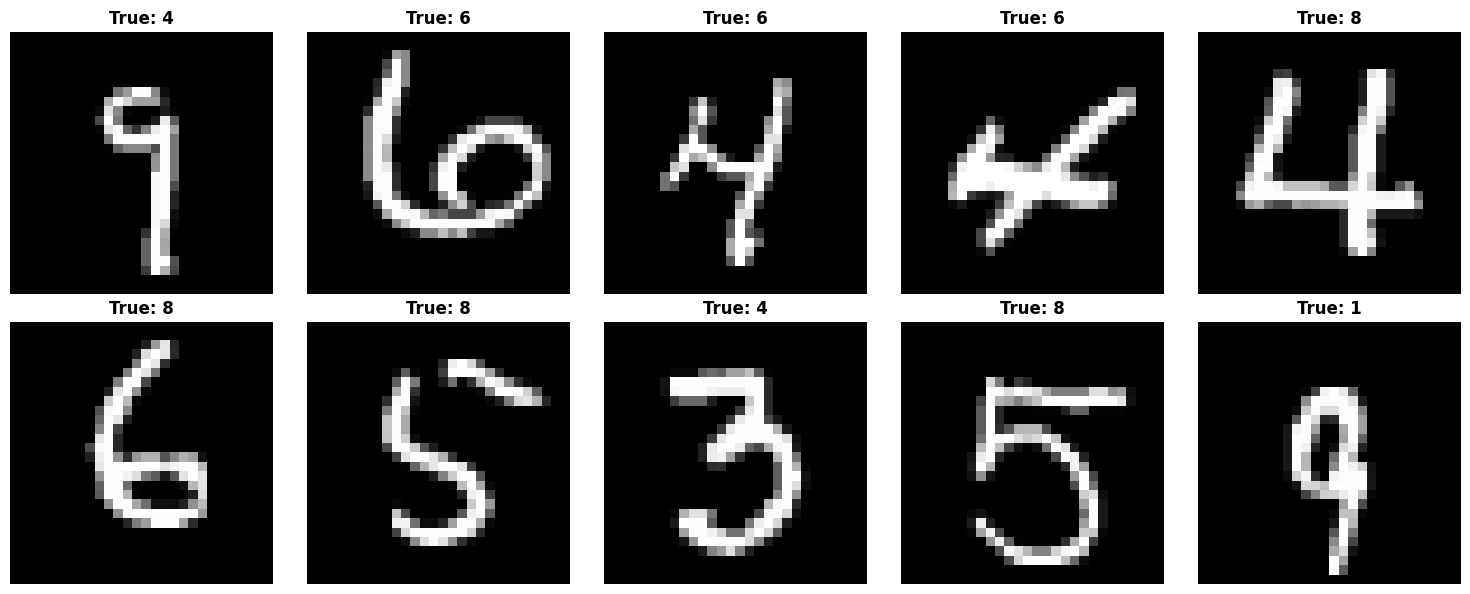

In [ ]:
# Aufgabe 1: Daten laden (PyTorch)
import utils.visualization as vis

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np

# TODO: define transformations for the dataset


# TODO: load the MNIST dataset


# TODO: create data loaders



print(f"Shape eines Batches: {next(iter(train_loader))[0].shape}")
n_samples = 10
X = next(iter(train_loader))[0][:n_samples]
Y = next(iter(train_loader))[1][:n_samples]
vis.plot_samples(X, Y)

### 1.2 Aufgabentyp

Überlegen Sie, welcher Aufgabentype des maschinellen Lernens hier vorliegt: pro Bild kommt genau eine handschriftliche Ziffer vor.

> <span style="color:#00A1E3">**Aufgabe 2 - Aufgabentyp**</span>
>
> Kommentieren Sie in der folgenden Zelle die Zeile ein, die den richtigen Aufgabentyp enthält. Führen Sie die Zelle anschließend aus, um Ihre Antwort zu validieren.

In [ ]:
from utils.test import test_task_type, TaskType

# TODO: uncomment the line containing the correct task type

#task_type = TaskType.REGRESSION
#task_type = TaskType.MULTI_LABEL_CLASSIFICATION
#task_type = TaskType.MULTI_CLASS_CLASSIFICATION
#task_type = TaskType.GENERATION

test_task_type(task_type)

✅ Da pro Bild nur genau eine Klasse korrekt sein kann, handelt es sich um eine Multi-Class Classification.


### 1.3 Aktivierungsfunktion

Überlegen Sie, welche Aktivierungsfunktion Sie auf die Modellausgabe anwenden müssen, wenn genau eine Klasse pro Bild vorkommt.


> <span style="color:#00A1E3">**Aufgabe 3 - Aktivierungsfunktion**</span>
>
> Kommentieren Sie in der folgenden Zelle die Zeile ein, die die richtige Aktivierungsfunktion enthält. Führen Sie die Zelle anschließend aus, um Ihre Antwort zu validieren.

In [ ]:
from utils.test import test_activation_type, ActivationType

# TODO: uncomment the line containing the correct activation type

#activation_type = ActivationType.RELU
#activation_type = ActivationType.SIGMOID
#activation_type = ActivationType.SOFTMAX
#activation_type = ActivationType.TANH

test_activation_type(activation_type)

✅ Softmax ist die richtige Wahl für Multi-Class Classification, da sie die Ausgaben in Wahrscheinlichkeiten umwandelt, die sich auf 1 summieren.
   Außerdem führt Softmax eine Klassenkonkurrenz ein, was hohe Werte verstärkt und niedrige Werte weiter abschwächt.


### 1.4 Verlustfunktion

Überlegen Sie, welche Verlustfunktion Sie auf die Modellausgabe anwenden müssen, wenn genau eine Klasse pro Bild vorkommt.


> <span style="color:#00A1E3">**Aufgabe 4 - Verlustfunktion**</span>
>
> Kommentieren Sie in der folgenden Zelle die Zeile ein, die die richtige Verlustfunktion enthält. Führen Sie die Zelle anschließend aus, um Ihre Antwort zu validieren.

In [ ]:
from utils.test import test_loss_type, LossType

# TODO: uncomment the line containing the correct loss type

#loss_type = LossType.MSE
#loss_type = LossType.BCE
#loss_type = LossType.CCE
#loss_type = LossType.MAE

test_loss_type(loss_type)

✅ CCE (Categorical Cross-Entropy) ist die richtige Wahl für Multi-Class Classification, da sie die Kreuzentropie zwischen den vorhergesagten Wahrscheinlichkeiten
   (nach Softmax) und den tatsächlichen Klassenlabels berechnet.


### 1.5 Modell definieren

Nun ist es Ihre Aufgabe, ein Convolutional Neural Network (CNN) zu entwickeln, welches in der Lage ist, den handschriftlichen MNIST-Nummern ein Label von 0-9 zuzuweisen. Dafür benötigen Sie ein CNN Backbone, welches relevante Features aus dem Bild extrahiert und in eine Repräsentation mit weniger Dimensionen überführt. Folgende Abbildung visualisiert ein kleines CNN, wobei Convolutions in <span style="color:#0e497d; font-weight:bold;">blau</span> und MaxPoolings in <span style="color:#d3023a; font-weight:bold;">rot</span> dargestellt werden.

<img src="images/cnn_scheme.png" style="max-width:400px"></img>

_Tipp: Sie benötigen etwa 1-4 Convolutions. Nutzen Sie ungerade Kernelgrößen zw. 1 und 5. Auf jede Convolution sollte ReLU und MaxPool folgen. Nutzen Sie für MaxPool Kernelgrößen von 2 bis max. 3 und Strides (`stride=...`), die der Kernelgröße entsprechen._

Für die Klassifikation müssen die Feature Maps (CNN Output) in flache Vektoren überführt (sogenannte Embeddings) überführt werden, um anschließend die Klassifikation mit einem Fully Connected Layer (`nn.Linear`) ausführen zu können.

> <span style="color:#00A1E3">**Aufgabe 5 - Modell definieren (PyTorch)**</span>
>
> Erstellen Sie ein Convolutional Neural Network (CNN) für die Bildklassifikation:
>
> 1. Definieren Sie eine Klasse `ConvNet`, die von `nn.Module` erbt
> 2. Implementieren Sie den Konstruktor `__init__`:
>    - Führen Sie im Konstruktor als erstes `super(ConvNet, self).__init__()` aus, um die `nn.Module` Klasse (von der wir ableiten) zu initialisieren
>    - Definieren Sie Ihr CNN Backbone. Beispiel für den ersten Block:<br>
>       `self.conv1 = nn.Conv2d(1, 16, kernel_size=3)`<br>
>       `self.relu1 = nn.ReLU()`<br>
>       `self.pool1 = nn.MaxPool2d(1)`
>    - Erstellen Sie `self.flatten = nn.Flatten(start_dim=1)`, um die Ausgabe des CCN's in einen flachen Vektor zu überführen. Der Parameter `start_dim=1` sagt aus, dass die 0. Dimension, also die Batches erhaltren bleiben. Ein $32\times 64 \times 8 \times 8$ Tensor würde somit in einen $32 \times 4,160$ Tensor überführt werden.
>    - Verwenden Sie am Ende **Fully Connected Layer** (`nn.Linear`) für die Klassifikation
>       - Für `nn.Linear` müssen Sie den Parameter `in_features` angeben. Das ist die Anzahl der Features des Embedding Vektors nach der Flatten Operation
>       - Wie Sie diese berechnen:
>           - Eingabebild: 1 Kanal x 28 Pixel x 28 Pixel
>           - Für jede Convolution reduziert sich die Bildgröße um `kernel_size-1`, die Anzahl der Kanäle erhöhrt sich auf `out_channels`
>           - Für MaxPool mit `kernel_size=2` und `stride=2` halbiert sich die Bildgröße (bei 3 $\to$ Dritel, usw.)
>           - Beispiel:<br>
>                - Input Image: (64, 1, 28, 28)<br>
>                - Convolution mit `kernel_size=3` und `out_channels=32` $\to$ (64, 32, 26, 26)<br>
>                - MaxPool mit `kernel_size=2` und `stride=2` $\to$ (64, 32, 13, 13)
>    - Abschließend müssen die Modellausgaben in Wahrscheinlichkeiten $[0; 1]$ konvertiert werden. Nutzen Sie die Aktivierungsfunktion aus der Vorüberlegung unter 1.3. Auswahl verfügbarer Aktivierungsfunktionen in PyTorch: `nn.ReLU()`, `nn.Sigmoid()`, `nn.Tanh()`, `nn.Softmax()`
>    - **Tipp**: Der Input hat 1 Kanal (Graustufen, 28×28 Pixel), der Output sollte 10 Klassen haben
> 3. Implementieren Sie die `forward(self, x:torch.Tensor)`-Methode:
>    - Führen Sie den Input durch alle Layer
>    - Beispiel für die ersten layer:<br>
>           `x = self.conv1(x)`<br>
>           `x = self.relu(x)`<br>
>           `x = self.pool1(x)`<br>
>           `...`
> 4. Erstellen Sie eine Instanz des Modells: `model = ConvNet()`
> 5. CUDA (Compute Unified Device Architecture) ist eine vin NVIDIA entwickelte Plattform, die es ermöglicht, Berechnungen auf der Grafikkarte durchzuführen. Diese ist für Matrixoperationen optimiert, was den Trainingsprozess deutlich beschleunigt. Setzen Sie mit `device=torch.device("cuda" if torch.cuda.is_available() else "cpu")` das Device auf CUDA, falls CUDA auf diesem Rechner zur Verfügung steht und verschieben Sie das Modell anschließend mit `model.to(device)` auf das entsprechende Device

In [ ]:
import torch
import torch.nn as nn

# TODO: define ConvNet Class


# TODO: instnciate ConvNet


# TODO: move model to device



# - Geben Sie die Modellarchitektur aus
print(f"Device: {device}")
print("Architektur:", model)

Device: mps
Architektur: ConvNet(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout2d(p=0.3, inplace=False)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (dropout2): Dropout2d(p=0.3, inplace=False)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (dropout3): Dropout2d(p=0.3, inplace=False)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=256, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)


> <span style="color:#00A1E3">**Aufgabe 6 - Training (PyTorch)**</span>
>
> 1. Instanziieren Sie die Loss-Funktion als `criterion=m.CCELoss()`
> 2. Instanziieren Sie den Optimierungsalgorithmus als `optimizer=optim.SGD(model.parameters(), lr=LEARNING_RATE)`
> 3. Bauen Sie die Schleife über die Epochen (`EPOCHS`) auf
> 4. Führen Sie in dieser Schleife `model.train()` aus. Dies versetzt das Modell in den Trainingsmodus. D. h. hier wird Dropout aktiv geschaltet usw.
> 5. Bauen Sie die Trainings-Schleife auf, welche mit `for X, Y in train_loader` über die Batches aus dem Trainings-Datensatz iteriert.<br>
>   In dieser Schleife:
>       - Daten ($X$, $Y$) auf Device verschieben (genau wie `model` oben)
>       - Alte Gradienten zurücksetzen: `optimizer.zero_grad()`
>       - Modelvorhersage $\hat{Y}=model(X)$
>       - Loss berechnen $L=f(\hat{Y}, Y)$: `loss = criterion(Y_hat, Y)`
>       - Gradienten zurückpropagieren: `loss.backward()`
>       - Parameter updaten: `optimizer.step()`
> 6. Nach der Trainings-Schleife:<br>
>       - Setzen Sie das Modell in den Validierungsmodus, um Dropout etc. zu deaktivieren: `model.eval()`<br>
> 7. Bauen Sie die Validierungs-Schleife auf, welche mit `for X, Y in val_loader` über die Batches aus dem Validierungs-Datensatz iteriert.<br>
>   In dieser Schleife:
>       - Daten ($X$, $Y$) auf Device verschieben (genau wie `model` oben)
>       - Hier auch Modellvorhersage, aber mit `with torch.no_grad():` und in nächter Zeile eingerückt `Y_hat = model(X)`, um keine Gradienten zu berechnen $\to$ nicht benötigt in Validierung, schneller
>       - Loss berechnen $L=f(\hat{Y}, Y)$: `loss = criterion(Y_hat, Y)`

Epoch 1/25 - Train Loss: 0.4659, Train Acc: 0.8515 - Val Loss: 0.1426, Val Acc: 0.9536
Epoch 2/25 - Train Loss: 0.1462, Train Acc: 0.9571 - Val Loss: 0.0724, Val Acc: 0.9775
Epoch 3/25 - Train Loss: 0.1081, Train Acc: 0.9676 - Val Loss: 0.0538, Val Acc: 0.9839
Epoch 4/25 - Train Loss: 0.0898, Train Acc: 0.9734 - Val Loss: 0.0576, Val Acc: 0.9832
Epoch 5/25 - Train Loss: 0.0795, Train Acc: 0.9762 - Val Loss: 0.0479, Val Acc: 0.9859
Epoch 6/25 - Train Loss: 0.0722, Train Acc: 0.9774 - Val Loss: 0.0493, Val Acc: 0.9864
Epoch 7/25 - Train Loss: 0.0649, Train Acc: 0.9797 - Val Loss: 0.0437, Val Acc: 0.9880
Epoch 8/25 - Train Loss: 0.0599, Train Acc: 0.9814 - Val Loss: 0.0406, Val Acc: 0.9878
Epoch 9/25 - Train Loss: 0.0549, Train Acc: 0.9826 - Val Loss: 0.0407, Val Acc: 0.9887
Epoch 10/25 - Train Loss: 0.0508, Train Acc: 0.9840 - Val Loss: 0.0377, Val Acc: 0.9895
Epoch 11/25 - Train Loss: 0.0492, Train Acc: 0.9848 - Val Loss: 0.0362, Val Acc: 0.9896
Epoch 12/25 - Train Loss: 0.0438, Train A

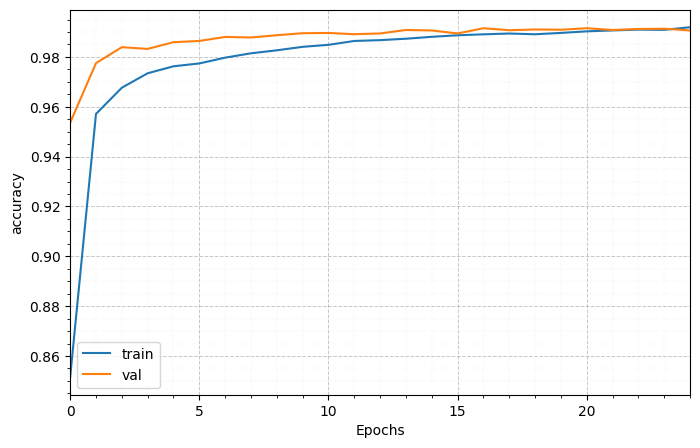

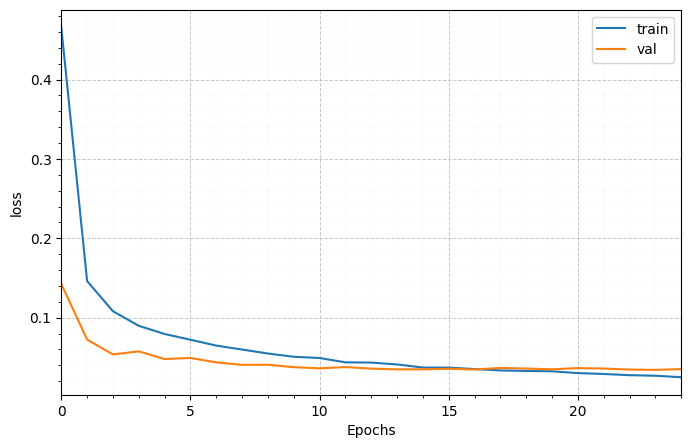

Modell gespeichert als 'mnist_pytorch_model.pth'


In [ ]:
import metrics as m
import torch
import torch.optim as optim
import utils.visualization as vis

losses_train, losses_val    = [], []
accs_train, accs_val        = [], []

LEARNING_RATE               = 0.05
EPOCHS                      = 25

# TODO: define loss


# TODO: define optimizer


for epoch in range(EPOCHS):
    # TODO: set the model to training mode (important for layers like dropout, batchnorm, etc.)


    # initialize lists to store losses and accuracies for the epoch
    losses_train_epoch, accs_train_epoch = [], []

    # BEGIN - training loop
    for X, Y in train_loader:
        # TODO: move data to device


        # TODO: PyTorch computes gradients automatically, so you don't need to manually compute them, 
        #       but you do need to zero them out before each backward pass.


        # TODO: forward pass


        # TODO: compute loss


        # TODO: propagate gradients


        # TODO: update parameters


        # compute metrics
        acc = m.accuracy(Y_hat, Y)
        losses_train_epoch.append(loss.item())
        accs_train_epoch.append(acc)
    # END - training loop

    # TODO: set the model to evaluation mode (deactivate dropout, etc.)


    # initialize lists to store losses and accuracies for the epoch
    losses_val_epoch, accs_val_epoch = [], []

    # BEGIN - validation loop
    for X, Y in val_loader:
        # TODO: move data to device


        # TODO: forward pass
                            # disable gradient computation for validation -> faster and not needed


        # TODO: compute loss


        # compute metrics
        acc = m.accuracy(Y_hat, Y)
        losses_val_epoch.append(loss.item())
        accs_val_epoch.append(acc)
    # END - validation loop

    # compute average losses and accuracies for the epoch
    avg_loss_train = np.mean(losses_train_epoch)
    avg_acc_train = np.mean(accs_train_epoch)
    avg_loss_val = np.mean(losses_val_epoch)
    avg_acc_val = np.mean(accs_val_epoch)

    losses_train.append(avg_loss_train)
    accs_train.append(avg_acc_train)
    losses_val.append(avg_loss_val)
    accs_val.append(avg_acc_val)

    print(f"Epoch {epoch+1}/{EPOCHS} - "
          f"Train Loss: {avg_loss_train:.4f}, Train Acc: {avg_acc_train:.4f} - "
          f"Val Loss: {avg_loss_val:.4f}, Val Acc: {avg_acc_val:.4f}")
    
vis.plot_series('accuracy', accs_train, accs_val)
vis.plot_series('loss', losses_train, losses_val)

# Modell speichern
torch.save(model.state_dict(), 'mnist_pytorch_model.pth')
print("Modell gespeichert als 'mnist_pytorch_model.pth'")

> <span style="color:#00A1E3">**Aufgabe 4 - Evaluation (PyTorch)**</span>
>
> 1. Setzen Sie das Modell in den Evaluationsmodus: `model.eval()`
> 2. Berechnen Sie die Genauigkeit auf dem Testset:
>    - Nutzen Sie `torch.no_grad()` für effiziente Inferenz (keine Gradienten)
>    - Zählen Sie korrekte Vorhersagen
>    - Berechnen Sie die Gesamtgenauigkeit
> 3. Visualisieren Sie 10 Testbilder mit ihren Vorhersagen und echten Labels:
>    - Nutzen Sie `torch.argmax()` für die vorhergesagte Klasse
>    - Färben Sie korrekte Vorhersagen grün, falsche rot

Führen Sie folgende Zelle aus, um Ihr trainiertes Modell zu testen:

/var/folders/49/y_60nmwx3mdc8dgg1tn_lhxr0000gn/T/ipykernel_12013/1034005659.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('mnist_pytor

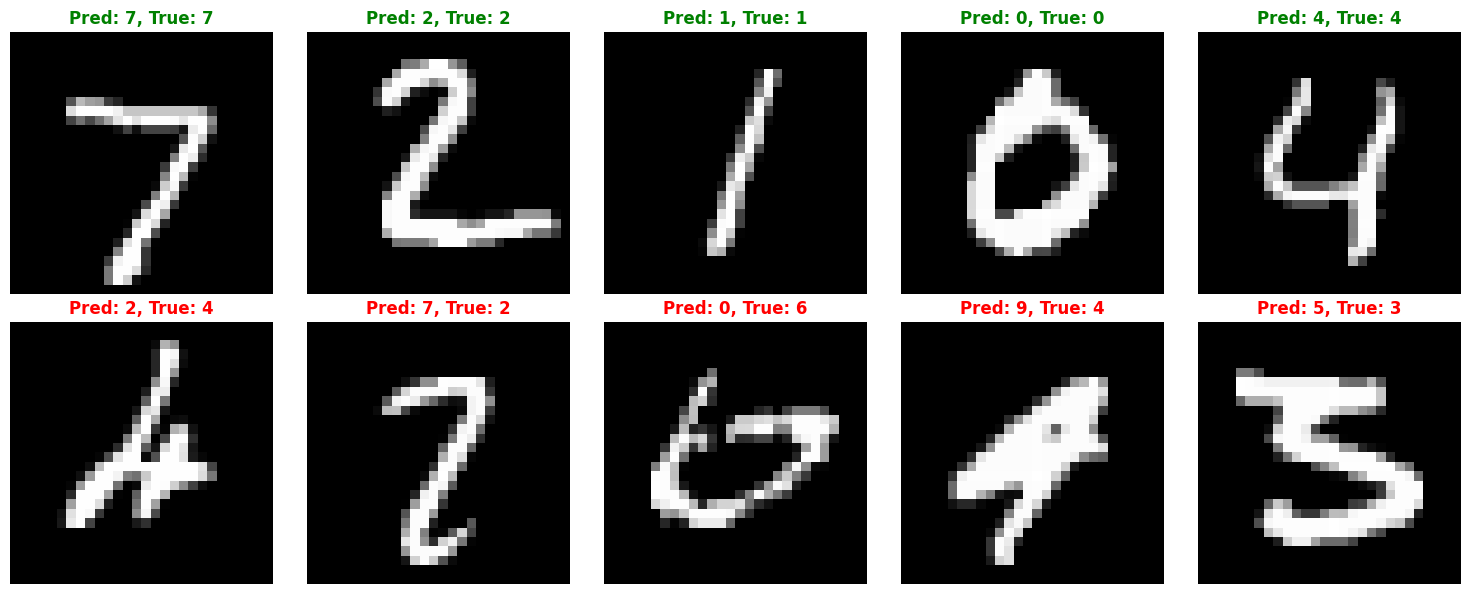

Test Accuracy: 0.9906


In [23]:
from utils.test import test_model_pytorch

model.load_state_dict(torch.load('mnist_pytorch_model.pth', map_location=device))

# Evaluation (PyTorch)
test_model_pytorch(model, val_loader, device)

---

## Teil 2: TensorFlow/Keras Implementation

TensorFlow ist ein von Google entwickeltes Framework mit Keras als High-Level-API für einfache Modellentwicklung.

### 2.1 Daten laden und vorbereiten

> <span style="color:#00A1E3">**Aufgabe 5 - Daten laden (TensorFlow)**</span>
>
> 1. Importieren Sie die benötigten Module:
>    - `tensorflow as tf`
>    - `from tensorflow import keras`
>    - `from tensorflow.keras import layers`
> 2. Laden Sie die MNIST-Daten:
>    - `(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()`
> 3. Bereiten Sie die Daten vor:
>    - Normalisieren Sie die Pixelwerte auf [0, 1]: Teilen Sie durch 255.0
>    - Fügen Sie eine Kanal-Dimension hinzu: `x_train = x_train[..., np.newaxis]`
>    - Konvertieren Sie Labels in kategoriale Form: `y_train = keras.utils.to_categorical(y_train, 10)`
> 4. Geben Sie die Formen der Daten aus
> 5. Visualisieren Sie die ersten 6 Bilder mit ihren Labels

In [9]:
# Aufgabe 5: Daten laden (TensorFlow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import utils.visualization as vis

# TODO: Ihr Code hier
# - Daten laden
# - Normalisieren
# - Kanal-Dimension hinzufügen
# - One-Hot Encoding


# Visualisierung der ersten 6 Bilder (vorgefertigt)
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    axes[i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {y_train[i]}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'tensorflow'

> <span style="color:#00A1E3">**Aufgabe 6 - Modell definieren (TensorFlow/Keras)**</span>
>
> Erstellen Sie ein CNN mit der Sequential API:
>
> 1. Erstellen Sie ein `keras.Sequential`-Modell mit einer Liste von Layern
> 2. Fügen Sie folgende Layer-Typen hinzu:
>    - **Input Layer**: `layers.Input(shape=(28, 28, 1))` - definiert die Eingabegröße
>    - **Conv2D Layer**: `layers.Conv2D(filters, kernel_size, activation='relu')` - für Feature-Extraktion
>    - **MaxPooling2D**: `layers.MaxPooling2D(pool_size)` - zur Dimensionsreduktion
>    - **Flatten**: `layers.Flatten()` - konvertiert 2D zu 1D
>    - **Dense Layer**: `layers.Dense(units, activation='relu')` - Fully Connected Layer
>    - **Dropout**: `layers.Dropout(rate)` - zur Regularisierung (optional)
>    - **Output Layer**: `layers.Dense(10, activation='softmax')` - 10 Klassen mit Softmax
> 3. Kompilieren Sie das Modell:
>    - Loss: `'categorical_crossentropy'` (für One-Hot encodierte Labels)
>    - Optimizer: `'adam'` oder andere
>    - Metriken: `['accuracy']`
> 4. Geben Sie die Modellzusammenfassung aus: `model_tf.summary()`
>
> **Experimentieren Sie mit:**

> - Anzahl und Tiefe der Convolutional Blöcke> - Größe der Dense Layer

> - Anzahl der Filter (z.B. 16, 32, 64)> - Pooling-Größe (z.B. 2×2, 3×3)
> - Kernel-Größe (z.B. 3×3, 5×5)

In [ ]:
# Aufgabe 6: Modell definieren (TensorFlow/Keras)

# TODO: Ihr Code hier
# - Erstellen Sie ein Sequential Modell
# - Kompilieren Sie das Modell
# - Geben Sie die Summary aus


> <span style="color:#00A1E3">**Aufgabe 7 - Training (TensorFlow)**</span>
>
> 1. Trainieren Sie das Modell mit `model.fit()`:
>    - Training Data: `x_train`, `y_train`
>    - Batch Size: `batch_size=64`
>    - Epochs: `epochs=5`
>    - Validation Split: `validation_split=0.1` (10% der Trainingsdaten für Validierung)
> 2. Speichern Sie die History: `history = model.fit(...)`
> 3. Plotten Sie den Trainingsverlauf:
>    - Trainings- und Validierungsverlust über Epochen
>    - Trainings- und Validierungsgenauigkeit über Epochen

In [ ]:
# Aufgabe 7: Training (TensorFlow)

# TODO: Ihr Code hier
# - Trainieren Sie das Modell mit model.fit()
# - Speichern Sie die History


# Visualisierung des Trainingsverlaufs (vorgefertigt)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(history.history['loss'], label='Training Loss', marker='o')
ax1.plot(history.history['val_loss'], label='Validation Loss', marker='s')
ax1.set_title('Modell Loss über Epochen', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoche', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
ax2.set_title('Modell Genauigkeit über Epochen', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoche', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTraining abgeschlossen!")

> <span style="color:#00A1E3">**Aufgabe 8 - Evaluation (TensorFlow)**</span>
>
> 1. Evaluieren Sie das Modell auf dem Testset:
>    - `test_loss, test_acc = model.evaluate(x_test, y_test)`
>    - Geben Sie die Testergebnisse aus
> 2. Machen Sie Vorhersagen:
>    - `predictions = model.predict(x_test[:10])`
>    - Verwenden Sie `np.argmax()` für die vorhergesagte Klasse
> 3. Visualisieren Sie 10 Testbilder mit Vorhersagen:
>    - Vergleichen Sie vorhergesagte und echte Labels
>    - Färben Sie korrekte Vorhersagen grün, falsche rot

In [ ]:
# Aufgabe 8: Evaluation (TensorFlow)

# TODO: Ihr Code hier
# - Evaluieren Sie das Modell
# - Machen Sie Vorhersagen auf den ersten 10 Testbildern


# Visualisierung von Vorhersagen (vorgefertigt)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(x_test[i].squeeze(), cmap='gray')
    
    pred_label = predicted_labels[i]
    true_label = true_labels[i]
    
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'Pred: {pred_label}, True: {true_label}', 
                      color=color, fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Modell speichern
model_tf.save('mnist_tensorflow_model.h5')
print("\nModell gespeichert als 'mnist_tensorflow_model.h5'")

---

## Teil 3: Vergleich und Experimente

### Vergleich der Frameworks

| Aspekt | PyTorch | TensorFlow/Keras |
|--------|---------|------------------|
| **Syntax** | Explizit, pythonisch | High-Level, kompakt |
| **Modelldef.** | Klassen mit `nn.Module` | Sequential oder Functional API |
| **Training** | Manuelle Schleife | `model.fit()` |
| **Dynamik** | Dynamischer Graph | Statischer Graph (eager execution möglich) |
| **Debugging** | Einfacher (Python-native) | Komplexer in Graph-Mode |
| **Popularität** | Forschung, Flexibilität | Produktion, Deployment |

### Experimente

> <span style="color:#00A1E3">**Aufgabe 9 - Experimentieren Sie!**</span>
>
> Testen Sie verschiedene Konfigurationen und beobachten Sie die Auswirkungen:
>
> 1. **Architektur**:
>    - Fügen Sie mehr Convolutional Layer hinzu
>    - Ändern Sie die Anzahl der Filter (z.B. 16, 64, 128)
>    - Experimentieren Sie mit der Größe der Fully Connected Layer
>
> 2. **Hyperparameter**:
>    - Lernrate: `0.0001`, `0.001`, `0.01`
>    - Batch Size: `32`, `64`, `128`
>    - Dropout Rate: `0.3`, `0.5`, `0.7`
>    - Epochs: `3`, `5`, `10`
>
> 3. **Optimizer**:
>    - PyTorch: `optim.SGD()`, `optim.RMSprop()`, `optim.Adam()`
>    - TensorFlow: `'sgd'`, `'rmsprop'`, `'adam'`
>
> 4. **Data Augmentation**:
>    - Fügen Sie Datenverstärkung hinzu (Rotation, Zoom, etc.)
>
> Welche Konfiguration liefert die beste Testgenauigkeit?

In [ ]:
# Aufgabe 9: Experimentieren Sie hier mit verschiedenen Konfigurationen

# Beispiel 1: Tieferes Netzwerk mit mehr Convolutional Layern (TensorFlow)
# model_deep = keras.Sequential([
#     layers.Input(shape=(28, 28, 1)),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Flatten(),
#     layers.Dense(256, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(10, activation='softmax')
# ])

# Beispiel 2: Verschiedene Lernraten testen
# learning_rates = [0.0001, 0.001, 0.01]
# for lr in learning_rates:
#     optimizer = keras.optimizers.Adam(learning_rate=lr)
#     model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
#     print(f"\nTraining mit Lernrate: {lr}")
#     # history = model.fit(...)

# Beispiel 3: Data Augmentation (TensorFlow)
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# datagen = ImageDataGenerator(
#     rotation_range=10,
#     zoom_range=0.1,
#     width_shift_range=0.1,
#     height_shift_range=0.1
# )
# datagen.fit(x_train)
# # history = model.fit(datagen.flow(x_train, y_train_categorical, batch_size=64), ...)

# Beispiel 4: Batch Normalization hinzufügen
# model_bn = keras.Sequential([
#     layers.Input(shape=(28, 28, 1)),
#     layers.Conv2D(32, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),
#     layers.Conv2D(64, (3, 3), activation='relu'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2)),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(10, activation='softmax')
# ])

# Beispiel 5: SGD mit Momentum (PyTorch)
# optimizer_sgd = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print("Hier können Sie mit verschiedenen Architekturen und Hyperparametern experimentieren!")
print("Entkommentieren Sie die Beispiele oben oder erstellen Sie Ihre eigenen Varianten.")

---

## Zusammenfassung

Sie haben erfolgreich:
- ✅ MNIST-Daten geladen und visualisiert
- ✅ CNN-Modelle in PyTorch und TensorFlow definiert
- ✅ Modelle trainiert und evaluiert
- ✅ Die Unterschiede beider Frameworks kennengelernt
- ✅ Mit verschiedenen Hyperparametern experimentiert

### Nächste Schritte

- Implementieren Sie komplexere Architekturen (ResNet, VGG)
- Testen Sie andere Datasets (CIFAR-10, Fashion-MNIST)
- Exportieren und deployen Sie Ihre Modelle
- Lernen Sie Transfer Learning kennen

**Viel Erfolg beim Experimentieren!** 🚀

<h1>Coding Session #4 - MNIST Handschrifterkennung mit PyTorch und TensorFlow</h1>

Führen Sie folgende Zelle aus, um alle benötigten Bibliotheken zu installieren:

In [ ]:
!pip install -r requirements.txt

## Ziel

In dieser Coding Session sollen Sie die Handschrifterkennung auf dem MNIST-Dataset mit zwei der beliebtesten Deep Learning Frameworks durchführen:
1. **PyTorch** - Ein dynamisches Framework mit pythonischem Design
2. **TensorFlow/Keras** - Ein leistungsstarkes Framework mit High-Level-API

Sie werden lernen:
- Wie man Daten lädt und vorverarbeitet
- Wie man neuronale Netze definiert
- Wie man Modelle trainiert und evaluiert
- Die Unterschiede und Gemeinsamkeiten beider Frameworks

## Das MNIST-Dataset

MNIST (Modified National Institute of Standards and Technology) ist ein klassisches Dataset für Handschrifterkennung:
- **60.000 Trainingsbilder** und **10.000 Testbilder**
- Bilder sind **28×28 Pixel** groß in Graustufen
- **10 Klassen**: Ziffern von 0 bis 9

<img src="https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png" width="400px"></img>

> <span style="color:#00A1E3">**Aufgabe 1 - Daten laden (PyTorch)**</span>
>
> 1. Importieren Sie die benötigten Module:
>    - `torch`, `torch.nn`, `torch.optim`
>    - `torchvision.datasets`, `torchvision.transforms`
>    - `matplotlib.pyplot` und `numpy`
> 2. Definieren Sie eine Transformation (`transform`), die:
>    - Die Bilder in Tensoren umwandelt (`transforms.ToTensor()`)
>    - Die Pixelwerte normalisiert: `transforms.Normalize((0.1307,), (0.3081,))`
> 3. Laden Sie die MNIST-Daten:
>    - Trainingsset: `train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)`
>    - Testset: `test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)`
> 4. Erstellen Sie DataLoader:
>    - `train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)`
>    - `test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)`
> 5. Visualisieren Sie die ersten 6 Bilder aus dem Trainingsset mit ihren Labels

In [ ]:
# Aufgabe 1: Daten laden (PyTorch)
# Ihr Code hier


# Visualisierung der ersten 6 Bilder (vorgefertigt)plt.show()

fig, axes = plt.subplots(1, 6, figsize=(12, 3))plt.tight_layout()

for i in range(6):    axes[i].axis('off')

    image, label = train_dataset[i]    axes[i].set_title(f'Label: {label}')

    # Denormalisieren für Visualisierung    axes[i].imshow(image.squeeze(), cmap='gray')
    image = image * 0.3081 + 0.1307

> <span style="color:#00A1E3">**Aufgabe 2 - Modell definieren (PyTorch)**</span>
>
> Erstellen Sie ein Convolutional Neural Network (CNN) für die Bildklassifikation:
>
> 1. Definieren Sie eine Klasse `ConvNet`, die von `nn.Module` erbt
> 2. Implementieren Sie den Konstruktor `__init__`:
>    - **Convolutional Layer 1**: `nn.Conv2d(1, 32, kernel_size=3)` - Input: 1 Kanal (Graustufen), Output: 32 Feature Maps
>    - **ReLU Aktivierung**: `nn.ReLU()`
>    - **Max Pooling 1**: `nn.MaxPool2d(2)` - Reduziert Dimensionen um Faktor 2
>    - **Convolutional Layer 2**: `nn.Conv2d(32, 64, kernel_size=3)` - 32 Input-Kanäle, 64 Output-Kanäle
>    - **ReLU Aktivierung**
>    - **Max Pooling 2**: `nn.MaxPool2d(2)`
>    - **Flatten**: Konvertiert 2D Feature Maps in 1D Vektor
>    - **Fully Connected Layer 1**: `nn.Linear(64 * 5 * 5, 128)` - 1600 Inputs, 128 Outputs
>    - **ReLU Aktivierung**
>    - **Dropout**: `nn.Dropout(0.5)` - Verhindert Overfitting
>    - **Fully Connected Layer 2**: `nn.Linear(128, 10)` - 128 Inputs, 10 Outputs (Klassen)
> 3. Implementieren Sie die `forward`-Methode:
>    - Führen Sie den Input durch alle Layer
>    - Verwenden Sie `x.view(x.size(0), -1)` zum Flatten nach den Conv-Layern
> 4. Erstellen Sie eine Instanz des Modells: `model = ConvNet()`
> 5. Geben Sie die Modellarchitektur aus: `print(model)`

In [ ]:
# Aufgabe 2: Modell definieren (PyTorch)
# Ihr Code hier


> <span style="color:#00A1E3">**Aufgabe 3 - Training (PyTorch)**</span>
>
> 1. Definieren Sie folgende Hyperparameter:
>    - `EPOCHS = 5` - Anzahl der Trainingsepochen
>    - `LEARNING_RATE = 0.001` - Lernrate für den Optimizer
> 2. Erstellen Sie den Loss (Verlustfunktion):
>    - `criterion = nn.CrossEntropyLoss()` - Für Klassifikation
> 3. Erstellen Sie den Optimizer:
>    - `optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)`
> 4. Implementieren Sie die Trainingsschleife:
>    - Äußere Schleife über Epochen
>    - Innere Schleife über Batches aus `train_loader`
>    - Für jeden Batch:
>      - `optimizer.zero_grad()` - Gradienten zurücksetzen
>      - `output = model(data)` - Forward Pass
>      - `loss = criterion(output, target)` - Loss berechnen
>      - `loss.backward()` - Backpropagation
>      - `optimizer.step()` - Parameter updaten
> 5. Geben Sie den Loss alle 100 Batches aus
> 6. Nach jeder Epoche: Berechnen Sie die Genauigkeit auf dem Testset

In [ ]:
# Aufgabe 3: Training (PyTorch)
# Ihr Code hier


> <span style="color:#00A1E3">**Aufgabe 4 - Evaluation (PyTorch)**</span>
>
> 1. Setzen Sie das Modell in den Evaluationsmodus: `model.eval()`
> 2. Berechnen Sie die Genauigkeit auf dem Testset:
>    - Nutzen Sie `torch.no_grad()` für effiziente Inferenz (keine Gradienten)
>    - Zählen Sie korrekte Vorhersagen
>    - Berechnen Sie die Gesamtgenauigkeit
> 3. Visualisieren Sie 10 Testbilder mit ihren Vorhersagen und echten Labels:
>    - Nutzen Sie `torch.argmax()` für die vorhergesagte Klasse
>    - Färben Sie korrekte Vorhersagen grün, falsche rot

In [ ]:
# Aufgabe 4: Evaluation (PyTorch)
# Ihr Code hier


# Visualisierung von Vorhersagen (vorgefertigt)print("Modell gespeichert als 'mnist_pytorch_model.pth'")

model.eval()torch.save(model.state_dict(), 'mnist_pytorch_model.pth')

fig, axes = plt.subplots(2, 5, figsize=(15, 6))# Modell speichern

axes = axes.ravel()

plt.show()

for i in range(10):plt.tight_layout()

    image, true_label = test_dataset[i]

        axes[i].axis('off')

    # Vorhersage machen                      color=color, fontsize=12, fontweight='bold')

    with torch.no_grad():    axes[i].set_title(f'Pred: {predicted_label}, True: {true_label}', 

        image_tensor = image.unsqueeze(0).to(device)    color = 'green' if predicted_label == true_label else 'red'

        output = model(image_tensor)    axes[i].imshow(image_display.squeeze(), cmap='gray')

        predicted_label = torch.argmax(output, dim=1).item()    # Plot

        

    # Denormalisieren für Visualisierung    image_display = image * 0.3081 + 0.1307

---

## Teil 2: TensorFlow/Keras Implementation

TensorFlow ist ein von Google entwickeltes Framework mit Keras als High-Level-API für einfache Modellentwicklung.

### 2.1 Daten laden und vorbereiten

> <span style="color:#00A1E3">**Aufgabe 5 - Daten laden (TensorFlow)**</span>
>
> 1. Importieren Sie die benötigten Module:
>    - `tensorflow as tf`
>    - `from tensorflow import keras`
>    - `from tensorflow.keras import layers`
> 2. Laden Sie die MNIST-Daten:
>    - `(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()`
> 3. Bereiten Sie die Daten vor:
>    - Normalisieren Sie die Pixelwerte auf [0, 1]: Teilen Sie durch 255.0
>    - Fügen Sie eine Kanal-Dimension hinzu: `x_train = x_train[..., np.newaxis]`
>    - Konvertieren Sie Labels in kategoriale Form: `y_train = keras.utils.to_categorical(y_train, 10)`
> 4. Geben Sie die Formen der Daten aus
> 5. Visualisieren Sie die ersten 6 Bilder mit ihren Labels

In [ ]:
# Aufgabe 5: Daten laden (TensorFlow)
# Ihr Code hier


# Visualisierung der ersten 6 Bilder (vorgefertigt)plt.show()

fig, axes = plt.subplots(1, 6, figsize=(12, 3))plt.tight_layout()

for i in range(6):    axes[i].axis('off')

    axes[i].imshow(x_train[i].squeeze(), cmap='gray')    axes[i].set_title(f'Label: {y_train[i]}')

> <span style="color:#00A1E3">**Aufgabe 6 - Modell definieren (TensorFlow/Keras)**</span>
>
> Erstellen Sie ein CNN mit der Sequential API:
>
> 1. Erstellen Sie ein `Sequential`-Modell
> 2. Fügen Sie Layer hinzu (verwenden Sie `model.add()` oder Liste):
>    - **Input Layer**: `layers.Input(shape=(28, 28, 1))`
>    - **Conv2D Layer 1**: `layers.Conv2D(32, kernel_size=(3, 3), activation='relu')`
>    - **MaxPooling2D**: `layers.MaxPooling2D(pool_size=(2, 2))`
>    - **Conv2D Layer 2**: `layers.Conv2D(64, kernel_size=(3, 3), activation='relu')`
>    - **MaxPooling2D**: `layers.MaxPooling2D(pool_size=(2, 2))`
>    - **Flatten**: `layers.Flatten()`
>    - **Dense Layer 1**: `layers.Dense(128, activation='relu')`
>    - **Dropout**: `layers.Dropout(0.5)`
>    - **Output Layer**: `layers.Dense(10, activation='softmax')` - 10 Klassen mit Softmax
> 3. Kompilieren Sie das Modell:
>    - Loss: `'categorical_crossentropy'`
>    - Optimizer: `'adam'`
>    - Metriken: `['accuracy']`
> 4. Geben Sie die Modellzusammenfassung aus: `model.summary()`

In [ ]:
# Aufgabe 6: Modell definieren (TensorFlow/Keras)
# Ihr Code hier


> <span style="color:#00A1E3">**Aufgabe 7 - Training (TensorFlow)**</span>
>
> 1. Trainieren Sie das Modell mit `model.fit()`:
>    - Training Data: `x_train`, `y_train`
>    - Batch Size: `batch_size=64`
>    - Epochs: `epochs=5`
>    - Validation Split: `validation_split=0.1` (10% der Trainingsdaten für Validierung)
> 2. Speichern Sie die History: `history = model.fit(...)`
> 3. Plotten Sie den Trainingsverlauf:
>    - Trainings- und Validierungsverlust über Epochen
>    - Trainings- und Validierungsgenauigkeit über Epochen

In [ ]:
# Aufgabe 7: Training (TensorFlow)
# Ihr Code hier


# Visualisierung des Trainingsverlaufs (vorgefertigt)print("\nTraining abgeschlossen!")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

plt.show()

# Lossplt.tight_layout()

ax1.plot(history.history['loss'], label='Training Loss', marker='o')

ax1.plot(history.history['val_loss'], label='Validation Loss', marker='s')ax2.grid(True, alpha=0.3)

ax1.set_title('Modell Loss über Epochen', fontsize=14, fontweight='bold')ax2.legend(fontsize=11)

ax1.set_xlabel('Epoche', fontsize=12)ax2.set_ylabel('Accuracy', fontsize=12)

ax1.set_ylabel('Loss', fontsize=12)ax2.set_xlabel('Epoche', fontsize=12)

ax1.legend(fontsize=11)ax2.set_title('Modell Genauigkeit über Epochen', fontsize=14, fontweight='bold')

ax1.grid(True, alpha=0.3)ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')

ax2.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
# Accuracy

> <span style="color:#00A1E3">**Aufgabe 8 - Evaluation (TensorFlow)**</span>
>
> 1. Evaluieren Sie das Modell auf dem Testset:
>    - `test_loss, test_acc = model.evaluate(x_test, y_test)`
>    - Geben Sie die Testergebnisse aus
> 2. Machen Sie Vorhersagen:
>    - `predictions = model.predict(x_test[:10])`
>    - Verwenden Sie `np.argmax()` für die vorhergesagte Klasse
> 3. Visualisieren Sie 10 Testbilder mit Vorhersagen:
>    - Vergleichen Sie vorhergesagte und echte Labels
>    - Färben Sie korrekte Vorhersagen grün, falsche rot

In [ ]:
# Aufgabe 8: Evaluation (TensorFlow)
# Ihr Code hier


# Visualisierung von Vorhersagen (vorgefertigt)print("\nModell gespeichert als 'mnist_tensorflow_model.h5'")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))model_tf.save('mnist_tensorflow_model.h5')

axes = axes.ravel()# Modell speichern



for i in range(10):plt.show()

    axes[i].imshow(x_test[i].squeeze(), cmap='gray')plt.tight_layout()

    

    pred_label = predicted_labels[i]    axes[i].axis('off')

    true_label = true_labels[i]                      color=color, fontsize=12, fontweight='bold')

        axes[i].set_title(f'Pred: {pred_label}, True: {true_label}', 
    color = 'green' if pred_label == true_label else 'red'

---

## Teil 3: Vergleich und Experimente

### Vergleich der Frameworks

| Aspekt | PyTorch | TensorFlow/Keras |
|--------|---------|------------------|
| **Syntax** | Explizit, pythonisch | High-Level, kompakt |
| **Modelldef.** | Klassen mit `nn.Module` | Sequential oder Functional API |
| **Training** | Manuelle Schleife | `model.fit()` |
| **Dynamik** | Dynamischer Graph | Statischer Graph (eager execution möglich) |
| **Debugging** | Einfacher (Python-native) | Komplexer in Graph-Mode |
| **Popularität** | Forschung, Flexibilität | Produktion, Deployment |

### Experimente

> <span style="color:#00A1E3">**Aufgabe 9 - Experimentieren Sie!**</span>
>
> Testen Sie verschiedene Konfigurationen und beobachten Sie die Auswirkungen:
>
> 1. **Architektur**:
>    - Fügen Sie mehr Convolutional Layer hinzu
>    - Ändern Sie die Anzahl der Filter (z.B. 16, 64, 128)
>    - Experimentieren Sie mit der Größe der Fully Connected Layer
>
> 2. **Hyperparameter**:
>    - Lernrate: `0.0001`, `0.001`, `0.01`
>    - Batch Size: `32`, `64`, `128`
>    - Dropout Rate: `0.3`, `0.5`, `0.7`
>    - Epochs: `3`, `5`, `10`
>
> 3. **Optimizer**:
>    - PyTorch: `optim.SGD()`, `optim.RMSprop()`, `optim.Adam()`
>    - TensorFlow: `'sgd'`, `'rmsprop'`, `'adam'`
>
> 4. **Data Augmentation**:
>    - Fügen Sie Datenverstärkung hinzu (Rotation, Zoom, etc.)
>
> Welche Konfiguration liefert die beste Testgenauigkeit?

In [ ]:
# Aufgabe 9: Experimentieren Sie hier mit verschiedenen Konfigurationen
# Ihr Code hier


---

## Zusammenfassung

Sie haben erfolgreich:
- ✅ MNIST-Daten geladen und visualisiert
- ✅ CNN-Modelle in PyTorch und TensorFlow definiert
- ✅ Modelle trainiert und evaluiert
- ✅ Die Unterschiede beider Frameworks kennengelernt
- ✅ Mit verschiedenen Hyperparametern experimentiert

### Nächste Schritte

- Implementieren Sie komplexere Architekturen (ResNet, VGG)
- Testen Sie andere Datasets (CIFAR-10, Fashion-MNIST)
- Exportieren und deployen Sie Ihre Modelle
- Lernen Sie Transfer Learning kennen

**Viel Erfolg beim Experimentieren!** 🚀